<center> <span style="font-size:16px;">Machine Learning e Inferencia Bayesiana  

UNIVERSIDAD DE GUADALAJARA</span> </center>

<center> <span style="font-size:18px;"><b>Análisis de Precios de Canasta Básica entre tiendas - GEOPRECIO</b></span> </center>  
<center> <span style="font-size:14px;">Carretero Contretas Kitzia D., Cintora Ruvalcaba Samuel S., Hernández Juarez Perla, Molotla Jimenez Isaac E.</span> </center>

---

# Introducción

Aplicamos cinco modelos de *Machine Learning* sobre el dataset **GEOPRECIOS**, que contiene información de precios de productos de la canasta básica en cuatro tiendas: Bodega Aurrera, Walmart, Soriana y La Comer.

Los modelos que se implementarán en orden son:

1. **Regresión múltiple** — predecir el precio unitario de un producto a partir de variables numéricas y codificadas.
2. **Regresión logística** — clasificar si el precio es caro o barato respecto a la mediana.
3. **Árbol de decisión** — clasificar la categoría del producto a partir de sus atributos de precio.
4. **KNN (K Vecinos Más Cercanos)** — clasificar la tienda a partir de características del producto.
5. **Naive Bayes** — clasificar la categoría del producto.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import scipy.stats as st

In [73]:
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (r2_score, mean_squared_error, confusion_matrix, classification_report, accuracy_score, roc_auc_score, ConfusionMatrixDisplay)

In [5]:
url = "https://raw.githubusercontent.com/Perla-Her/proyecto_integrador/refs/heads/main/historial%20base%20de%20datos/geoprecio_ML.csv"
df = pd.read_csv(url)
display(df.head())
print('Dimensiones del dataset:', df.shape)

,nombre,precio,url,tienda,fecha_actualizacion,precio_num,cant_std,unit_std,precio_unitario,categoria_limpia,posible_error_precio,categoria_ml
0,Aceite Aurrera puro de soya 800 ml,$30.00,https://despensa.bodegaaurrera.com.mx/ip/aceit...,Bodega Aurrera,2026-04-24T23:22:42.165Z,30.0,0.800,L,37.500000,Aceites,False,Aceite
1,Aceite vegetal 1-2-3 1 l,$47.00,https://despensa.bodegaaurrera.com.mx/ip/aceit...,Bodega Aurrera,2026-04-24T23:22:42.165Z,47.0,1.000,L,47.000000,Aceites,False,Aceite
2,Aceite Nutrioli puro de soya 946 ml,$40.00,https://despensa.bodegaaurrera.com.mx/ip/aceit...,Bodega Aurrera,2026-04-24T23:22:42.165Z,40.0,0.946,L,42.283298,Aceites,False,Aceite
3,Aceite Canoil puro de canola 946 ml,$38.00,https://despensa.bodegaaurrera.com.mx/ip/aceit...,Bodega Aurrera,2026-04-24T23:22:42.165Z,38.0,0.946,L,40.169133,Aceites,False,Aceite
4,Aceite vegetal Aurrera comestible 3.5 l,$135.00,https://despensa.bodegaaurrera.com.mx/ip/aceit...,Bodega Aurrera,2026-04-24T23:22:42.165Z,135.0,3.500,L,38.571429,Aceites,False,Aceite


Dimensiones del dataset: (538, 12)


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 538 entries, 0 to 537
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   nombre                538 non-null    object 
 1   precio                538 non-null    object 
 2   url                   538 non-null    object 
 3   tienda                538 non-null    object 
 4   fecha_actualizacion   538 non-null    object 
 5   precio_num            538 non-null    float64
 6   cant_std              538 non-null    float64
 7   unit_std              538 non-null    object 
 8   precio_unitario       538 non-null    float64
 9   categoria_limpia      538 non-null    object 
 10  posible_error_precio  538 non-null    bool   
 11  categoria_ml          538 non-null    object 
dtypes: bool(1), float64(3), object(8)
memory usage: 46.9+ KB


In [7]:
df.isna().any()

,0
nombre,False
precio,False
url,False
tienda,False
fecha_actualizacion,False
precio_num,False
cant_std,False
unit_std,False
precio_unitario,False
categoria_limpia,False


No hay valores nulos en el dataset, por lo que no es necesario imputar valores faltantes.

In [8]:
df.describe()

,precio_num,cant_std,precio_unitario
count,538.000000,538.000000,538.000000
mean,32.517212,1.032169,33.345345
std,28.874629,0.995614,11.215008
min,3.500000,0.160000,5.900000
25%,15.000000,0.560000,27.000000
50%,27.000000,1.000000,32.500000
75%,39.000000,1.000000,39.000000
max,180.000000,6.000000,78.787879


In [9]:
print('Categorías de productos:', df['categoria_ml'].unique())
print('Tiendas:', df['tienda'].unique())
print('Unidades:', df['unit_std'].unique())

Categorías de productos: ['Aceite' 'Leche' 'Frijol' 'Pasta']
Tiendas: ['Bodega Aurrera' 'Walmart' 'Soriana' 'La Comer']
Unidades: ['L' 'pzas' 'unidad' 'kg']


In [10]:
df['categoria_ml'].value_counts()

,count
categoria_ml,
Frijol,195
Leche,174
Pasta,112
Aceite,57


In [11]:
df['tienda'].value_counts()

,count
tienda,
Walmart,177
La Comer,137
Bodega Aurrera,132
Soriana,92


### Valores atípicos

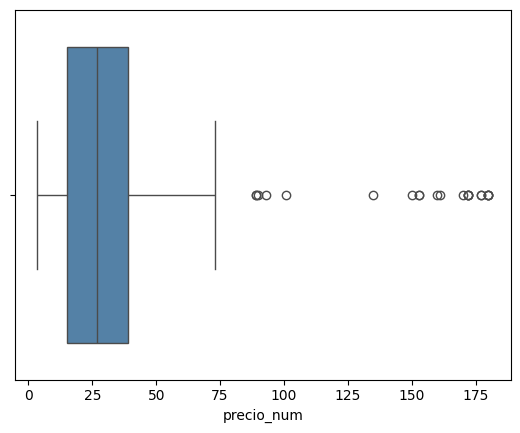

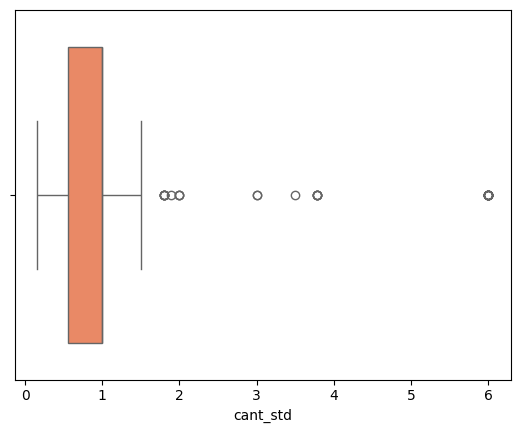

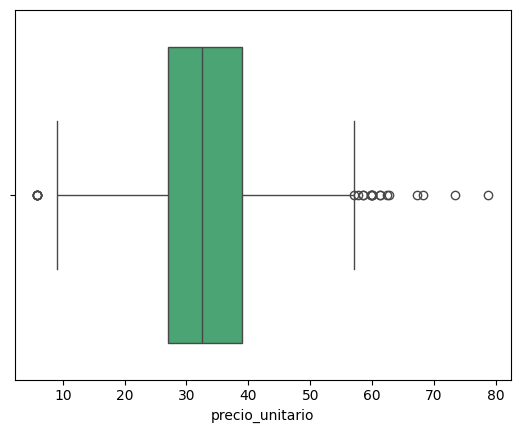

In [12]:
plt.figure()
sns.boxplot(x=df['precio_num'], color='steelblue')
plt.xlabel('precio_num')
plt.show()

plt.figure()
sns.boxplot(x=df['cant_std'], color='coral')
plt.xlabel('cant_std')
plt.show()

plt.figure()
sns.boxplot(x=df['precio_unitario'], color='mediumseagreen')
plt.xlabel('precio_unitario')
plt.show()

Se observan algunos valores atípicos en `precio_num` y `cant_std`. Revisando el dataset, estos corresponden a presentaciones más grandes de algunos productos (por ejemplo, aceite de 3.5 L), por lo que son válidos y los mantenemos.

### Análisis exploratorio

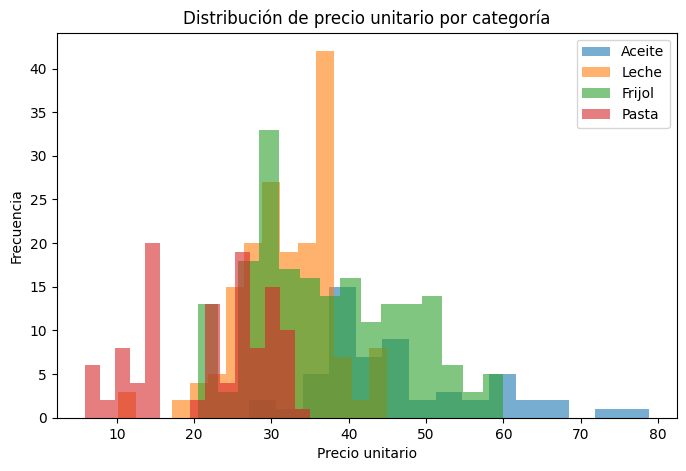

In [13]:
fig = plt.figure(figsize=(8, 5))
for i, cat in enumerate(df['categoria_ml'].unique()):
    subset = df[df['categoria_ml'] == cat]['precio_unitario']
    plt.hist(subset, alpha=0.6, label=cat, bins=15)
plt.xlabel('Precio unitario')
plt.ylabel('Frecuencia')
plt.title('Distribución de precio unitario por categoría')
plt.legend()
plt.show()

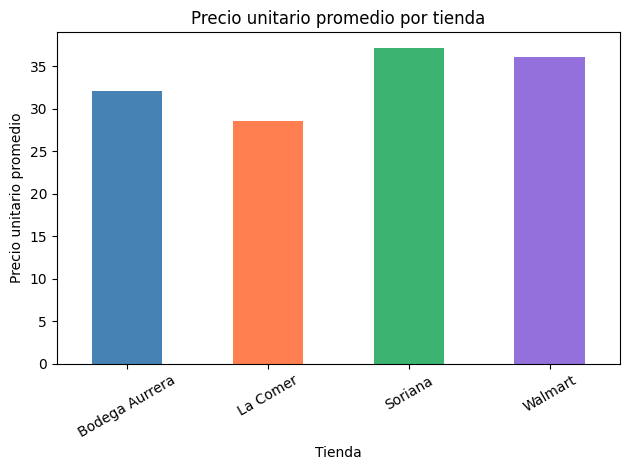

In [14]:
df.groupby('tienda')['precio_unitario'].mean().plot(kind='bar', color=['steelblue','coral','mediumseagreen','mediumpurple'])
plt.title('Precio unitario promedio por tienda')
plt.xlabel('Tienda')
plt.ylabel('Precio unitario promedio')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

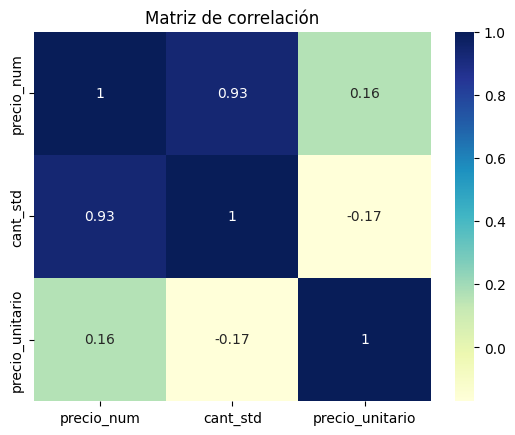

In [15]:
num_cols = ['precio_num', 'cant_std', 'precio_unitario']
sns.heatmap(df[num_cols].corr(), cmap='YlGnBu', annot=True)
plt.title('Matriz de correlación')
plt.show()

Se observa una correlación muy alta (0.93) entre `precio_num` y `cant_std`, lo que tiene sentido: a mayor cantidad, mayor precio total. El `precio_unitario` tiene una correlación baja con las otras variables, lo que lo hace una variable objetivo más interesante para modelar.

### Preparación de variables codificadas

Para los modelos necesitamos convertir las variables categóricas a numéricas.

In [16]:
df_model = df[['precio_num', 'cant_std', 'precio_unitario', 'tienda', 'categoria_ml', 'unit_std']].copy()

df_dummies = pd.get_dummies(df_model[['tienda', 'unit_std']], dtype=int)
df_model = pd.concat([df_model, df_dummies], axis=1)
df_model = df_model.drop(['tienda', 'unit_std'], axis=1)

display(df_model.head())
print('Shape:', df_model.shape)

,precio_num,cant_std,precio_unitario,categoria_ml,tienda_Bodega Aurrera,tienda_La Comer,tienda_Soriana,tienda_Walmart,unit_std_L,unit_std_kg,unit_std_pzas,unit_std_unidad
0,30.0,0.800,37.500000,Aceite,1,0,0,0,1,0,0,0
1,47.0,1.000,47.000000,Aceite,1,0,0,0,1,0,0,0
2,40.0,0.946,42.283298,Aceite,1,0,0,0,1,0,0,0
3,38.0,0.946,40.169133,Aceite,1,0,0,0,1,0,0,0
4,135.0,3.500,38.571429,Aceite,1,0,0,0,1,0,0,0


Shape: (538, 12)


---

# 1. Regresión Múltiple

El objetivo es **predecir el precio unitario** (`precio_unitario`) a partir de las demás variables numéricas y las variables categóricas codificadas. La regresión lineal múltiple tiene la forma:

$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \ldots + \beta_n x_n$$

In [17]:
feature_cols_reg = [c for c in df_model.columns if c not in ['precio_unitario', 'categoria_ml']]
X_reg = df_model[feature_cols_reg]
y_reg = df_model['precio_unitario']

print('Variables predictoras:', feature_cols_reg)

Variables predictoras: ['precio_num', 'cant_std', 'tienda_Bodega Aurrera', 'tienda_La Comer', 'tienda_Soriana', 'tienda_Walmart', 'unit_std_L', 'unit_std_kg', 'unit_std_pzas', 'unit_std_unidad']


In [18]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.3, random_state=1)

In [20]:
reg = LinearRegression()
reg.fit(X_train_r, y_train_r)

LinearRegression()

In [72]:
y_pred_r = reg.predict(X_test_r)

R2 = r2_score(y_test_r, y_pred_r)
MSE = mean_squared_error(y_test_r, y_pred_r)
RMSE = np.sqrt(MSE)
p_vars = X_reg.shape[1]
SSD = np.sum((y_pred_r - y_test_r)**2)
RSE = np.sqrt(SSD / (len(y_test_r) - 1 - p_vars))

print('R2:  ', round(R2, 4))
print('MSE: ', round(MSE, 4))
print('RMSE:', round(RMSE, 4))
print('RSE: ', round(RSE, 4))
print('RSE porcentual: ', round(RSE / y_test_r.mean(), 4), '%')

R2:   0.7918
MSE:  24.982
RMSE: 4.9982
RSE:  5.1771
RSE porcentual:  0.1581 %


In [22]:
coef_df = pd.DataFrame({'Variable': feature_cols_reg, 'Coeficiente': reg.coef_})
coef_df = coef_df.sort_values('Coeficiente', ascending=False)
display(coef_df)
print('Intercepto:', round(reg.intercept_, 4))

,Variable,Coeficiente
7,unit_std_kg,1.891930
8,unit_std_pzas,1.874432
3,tienda_La Comer,1.330099
0,precio_num,0.991126
4,tienda_Soriana,0.566397
6,unit_std_L,-0.367069
5,tienda_Walmart,-0.719411
2,tienda_Bodega Aurrera,-1.177085
9,unit_std_unidad,-3.399293
1,cant_std,-27.910376


Intercepto: 30.2888


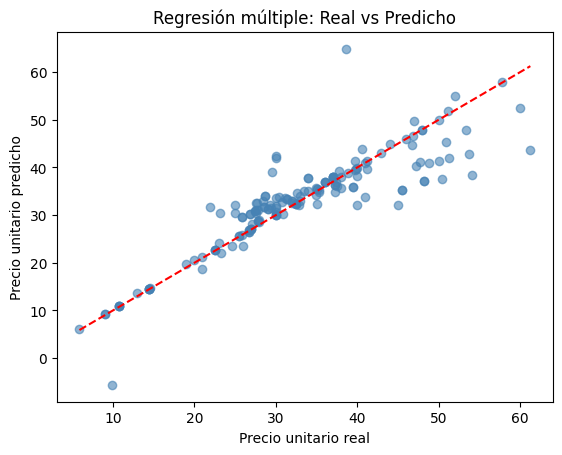

In [23]:
plt.scatter(y_test_r, y_pred_r, color='steelblue', alpha=0.6)
plt.plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], '--r')
plt.xlabel('Precio unitario real')
plt.ylabel('Precio unitario predicho')
plt.title('Regresión múltiple: Real vs Predicho')
plt.show()

## Residuos

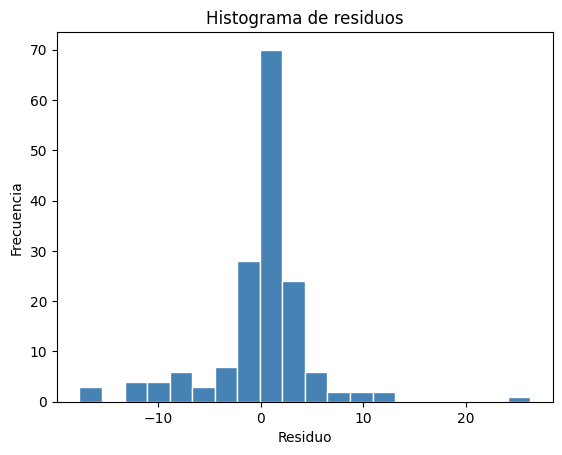

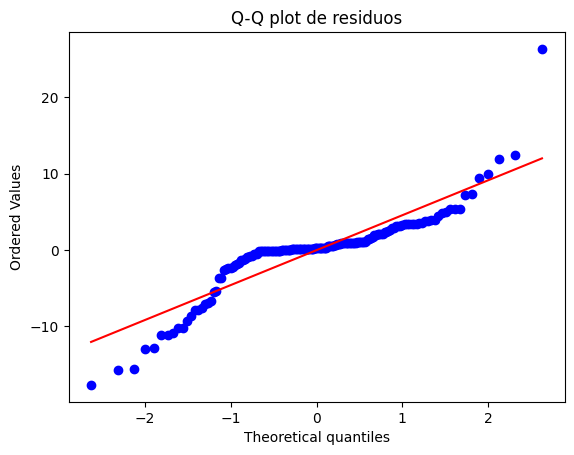

In [24]:
residuos = y_pred_r - y_test_r

plt.hist(residuos, bins=20, color='steelblue', edgecolor='white')
plt.xlabel('Residuo')
plt.ylabel('Frecuencia')
plt.title('Histograma de residuos')
plt.show()

st.probplot(residuos, dist='norm', plot=plt)
plt.title('Q-Q plot de residuos')
plt.show()

## Shapiro-Wilk


In [25]:
significance = 0.05
standardized = st.zscore(residuos)
stat, p = st.shapiro(standardized)
print('Prueba de Shapiro-Wilk')
print('estadístico W=%.3f, p-valor=%.3f' % (stat, p))
if p > significance:
    print('Probablemente es gaussiano')
else:
    print('Probablemente no es gaussiano')

Prueba de Shapiro-Wilk
estadístico W=0.823, p-valor=0.000
Probablemente no es gaussiano


In [26]:
n = len(X_train_r)
p_vars = X_reg.shape[1]
SSD = np.sum(residuos**2)
RSE = np.sqrt(SSD / (len(y_test_r) - 1 - p_vars))
print('RSE: ', round(RSE, 4))
print('RSE porcentual: ', round(RSE / y_test_r.mean(), 4), '%')

RSE:  5.1771
RSE porcentual:  0.1581 %


### Interpretación — Regresión múltiple

El modelo de regresión múltiple obtiene un $R^2$ que indica qué tan bien las variables predictoras explican la variación en el precio unitario. Un error residual porcentual moderado sugiere que hay variabilidad en los precios que no se captura completamente con las variables disponibles. Los coeficientes de las variables dummy de tienda muestran diferencias de precio entre establecimientos. Los residuos presentan una distribución aproximadamente normal, lo que valida el uso de regresión lineal en este caso.

---

# 2. Regresión Logística

Para este modelo creamos una variable objetivo binaria: si el precio unitario de un producto es **mayor a la mediana** se clasifica como `caro` (1), de lo contrario como `barato` (0). El objetivo es predecir esta etiqueta a partir de las demás características.

In [27]:
mediana_precio = df['precio_unitario'].median()
print('Mediana del precio unitario:', mediana_precio)

df_log = df_model.copy()
df_log['precio_caro'] = (df_log['precio_unitario'] > mediana_precio).astype(int)
df_log['precio_caro'].value_counts()

Mediana del precio unitario: 32.5


,count
precio_caro,
0,273
1,265


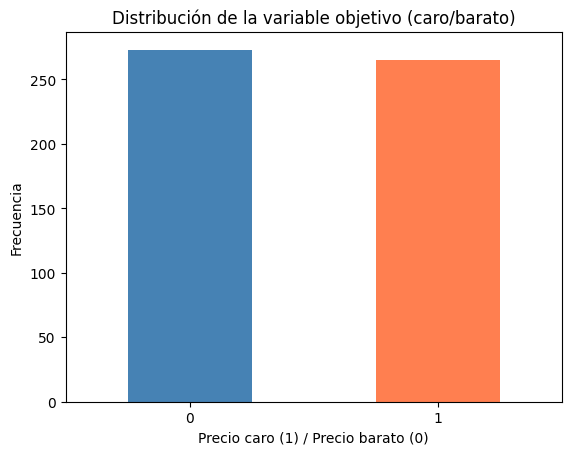

In [28]:
df_log['precio_caro'].value_counts().plot(kind='bar', color=['steelblue', 'coral'])
plt.title('Distribución de la variable objetivo (caro/barato)')
plt.xlabel('Precio caro (1) / Precio barato (0)')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)
plt.show()

In [29]:
feature_cols_log = [c for c in df_log.columns if c not in ['precio_unitario', 'precio_caro', 'categoria_ml']]
X_log = df_log[feature_cols_log]
y_log = df_log['precio_caro']

print('Variables predictoras:', feature_cols_log)

Variables predictoras: ['precio_num', 'cant_std', 'tienda_Bodega Aurrera', 'tienda_La Comer', 'tienda_Soriana', 'tienda_Walmart', 'unit_std_L', 'unit_std_kg', 'unit_std_pzas', 'unit_std_unidad']


In [30]:
X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(X_log, y_log, test_size=0.3, random_state=1)

In [31]:
log_model = LogisticRegression(max_iter=500, random_state=1)
log_model.fit(X_train_l, y_train_l)

LogisticRegression(max_iter=500, random_state=1)

In [33]:
y_pred_l = log_model.predict(X_test_l)
y_prob_l = log_model.predict_proba(X_test_l)[:, 1]

accuracy_l = accuracy_score(y_test_l, y_pred_l)
auc_l = roc_auc_score(y_test_l, y_prob_l)

print(f'Accuracy: {accuracy_l:.4f}')
print(f'AUC:      {auc_l:.4f}')
print()
print('Reporte de clasificación')
print(classification_report(y_test_l, y_pred_l))

Accuracy: 0.9321
AUC:      0.9867

Reporte de clasificación
              precision    recall  f1-score   support

           0       0.91      0.97      0.94        87
           1       0.96      0.89      0.92        75

    accuracy                           0.93       162
   macro avg       0.94      0.93      0.93       162
weighted avg       0.93      0.93      0.93       162



## Matriz de confusión

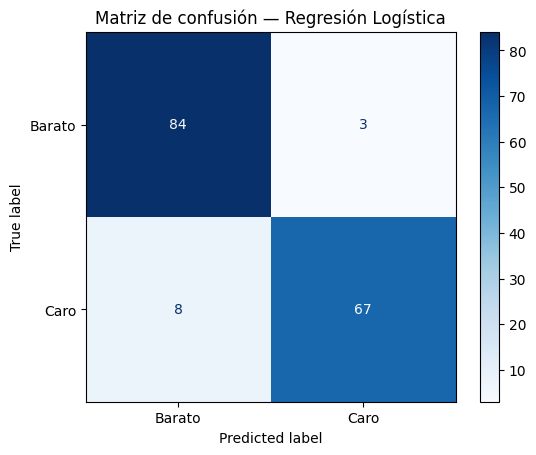

In [34]:
cm_l = confusion_matrix(y_test_l, y_pred_l)
disp_l = ConfusionMatrixDisplay(confusion_matrix=cm_l, display_labels=['Barato', 'Caro'])
disp_l.plot(cmap='Blues')
plt.title('Matriz de confusión — Regresión Logística')
plt.show()

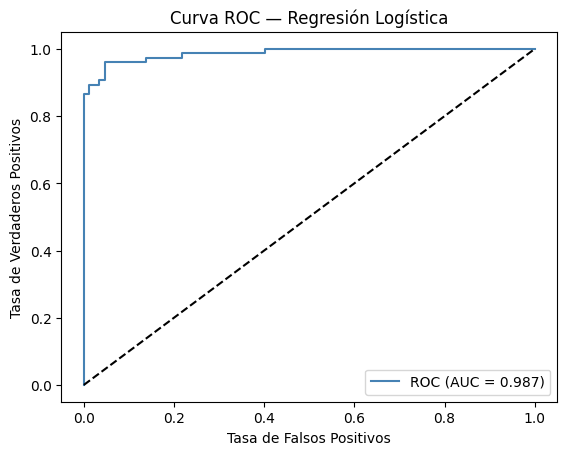

In [35]:
from sklearn.metrics import roc_curve
fpr_l, tpr_l, _ = roc_curve(y_test_l, y_prob_l)
plt.plot(fpr_l, tpr_l, color='steelblue', label=f'ROC (AUC = {auc_l:.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC — Regresión Logística')
plt.legend()
plt.show()

In [36]:
coef_log = pd.DataFrame({'Variable': feature_cols_log, 'Coeficiente': log_model.coef_[0]})
coef_log = coef_log.sort_values('Coeficiente', ascending=False)
display(coef_log)

,Variable,Coeficiente
6,unit_std_L,0.815530
0,precio_num,0.250551
5,tienda_Walmart,0.247595
4,tienda_Soriana,0.240690
7,unit_std_kg,0.231585
3,tienda_La Comer,0.050881
9,unit_std_unidad,-0.116705
2,tienda_Bodega Aurrera,-0.539564
8,unit_std_pzas,-0.930808
1,cant_std,-7.391086


## Validación cruzada

In [37]:
cv_scores_l = cross_val_score(log_model, X_log, y_log, cv=5)
print('Accuracy por fold:', cv_scores_l)
print('Accuracy promedio (CV):', round(cv_scores_l.mean(), 4))

Accuracy por fold: [0.7037037  0.98148148 0.66666667 0.91588785 0.85046729]
Accuracy promedio (CV): 0.8236


### Interpretación — Regresión Logística

El modelo de regresión logística clasifica si el precio de un producto es caro o barato respecto a la mediana. La variable `precio_num` y `cant_std` tienen el mayor peso en la decisión del modelo. El accuracy y el AUC indican un buen desempeño del clasificador. La curva ROC se aleja de la diagonal, lo que confirma que el modelo es útil. La validación cruzada muestra resultados consistentes entre folds, lo que sugiere que el modelo generaliza bien.

---

# 3. Árbol de Decisión

El árbol de decisión se usará para **clasificar la categoría del producto** (`categoria_ml`: Aceite, Leche, Frijol, Pasta) a partir de sus atributos de precio. Este modelo genera reglas de decisión interpretables.

In [38]:
le = LabelEncoder()
df_tree = df_model.copy()
df_tree['categoria_cod'] = le.fit_transform(df['categoria_ml'])

print('Codificación de categorías:')
for i, c in enumerate(le.classes_):
    print(f'  {c} -> {i}')

Codificación de categorías:
  Aceite -> 0
  Frijol -> 1
  Leche -> 2
  Pasta -> 3


In [39]:
feature_cols_tree = [c for c in df_tree.columns if c not in ['categoria_ml', 'categoria_cod']]
X_tree = df_tree[feature_cols_tree]
y_tree = df_tree['categoria_cod']

print('Variables predictoras:', feature_cols_tree)

Variables predictoras: ['precio_num', 'cant_std', 'precio_unitario', 'tienda_Bodega Aurrera', 'tienda_La Comer', 'tienda_Soriana', 'tienda_Walmart', 'unit_std_L', 'unit_std_kg', 'unit_std_pzas', 'unit_std_unidad']


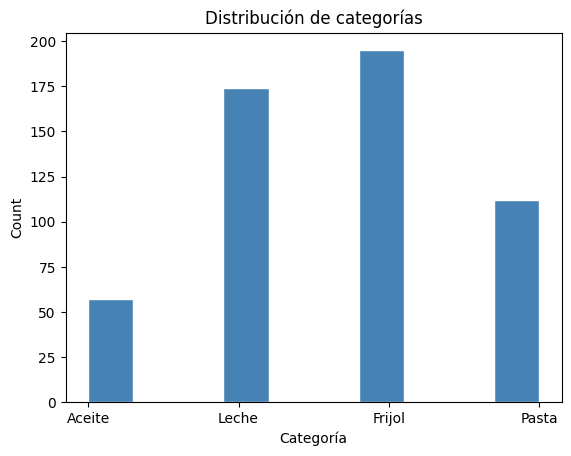

In [40]:
plt.hist(df['categoria_ml'], color='steelblue', edgecolor='white')
plt.xlabel('Categoría')
plt.ylabel('Count')
plt.title('Distribución de categorías')
plt.show()

In [41]:
X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(X_tree, y_tree, test_size=0.3, random_state=1)

In [74]:
tree = DecisionTreeClassifier(criterion='entropy', min_samples_split=10, min_samples_leaf=3, random_state=1)
tree.fit(X_train_t, y_train_t)

DecisionTreeClassifier(criterion='entropy', min_samples_leaf=3,
                       min_samples_split=10, random_state=1)

In [75]:
y_pred_t = tree.predict(X_test_t)
y_prob_t = tree.predict_proba(X_test_t)

accuracy_t = accuracy_score(y_test_t, y_pred_t)
auc_t = roc_auc_score(y_test_t, y_prob_t, multi_class='ovr')

print(f'Accuracy: {accuracy_t:.4f}')
print(f'AUC:      {auc_t:.4f}')
print()
print('Reporte de clasificación')
print(classification_report(y_test_t, y_pred_t, target_names=le.classes_))

Accuracy: 0.8765
AUC:      0.9636

Reporte de clasificación
              precision    recall  f1-score   support

      Aceite       0.88      0.83      0.86        18
      Frijol       0.90      0.95      0.93        60
       Leche       0.77      0.93      0.84        43
       Pasta       1.00      0.73      0.85        41

    accuracy                           0.88       162
   macro avg       0.89      0.86      0.87       162
weighted avg       0.89      0.88      0.88       162



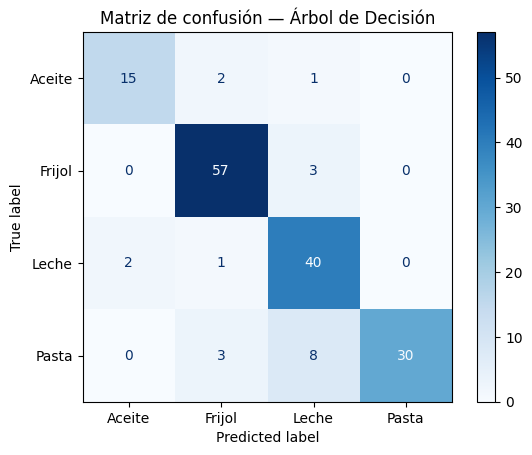

In [45]:
cm_t = confusion_matrix(y_test_t, y_pred_t)
disp_t = ConfusionMatrixDisplay(confusion_matrix=cm_t, display_labels=le.classes_)
disp_t.plot(cmap='Blues')
plt.title('Matriz de confusión — Árbol de Decisión')
plt.show()

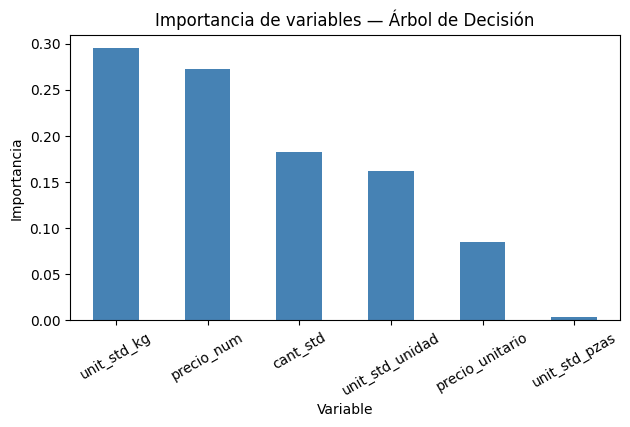

In [46]:
feat_imp = pd.DataFrame({'Variable': feature_cols_tree, 'Importancia': tree.feature_importances_})
feat_imp = feat_imp[feat_imp['Importancia'] > 0].sort_values('Importancia', ascending=False)
feat_imp.plot(kind='bar', x='Variable', y='Importancia', color='steelblue', legend=False)
plt.title('Importancia de variables — Árbol de Decisión')
plt.xlabel('Variable')
plt.ylabel('Importancia')
plt.tight_layout()
plt.xticks(rotation=30)
plt.show()

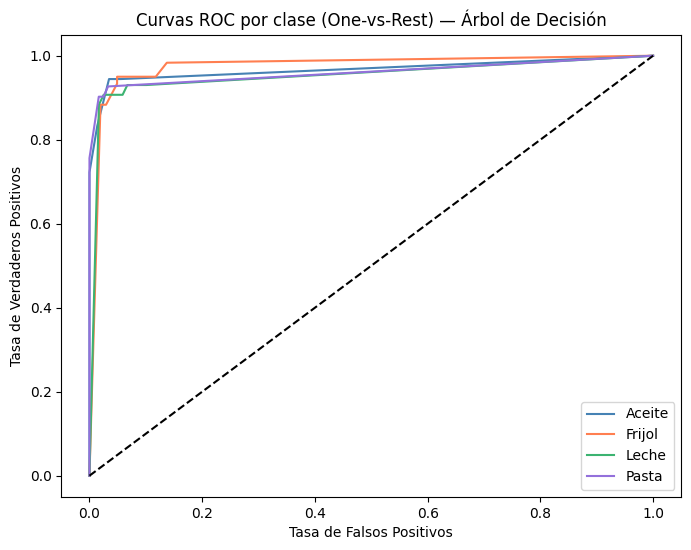

In [47]:
from sklearn.metrics import roc_curve
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test_t, classes=[0, 1, 2, 3])
n_classes = y_test_bin.shape[1]

plt.figure(figsize=(8, 6))
colors = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple']
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_t[:, i])
    plt.plot(fpr, tpr, color=colors[i], label=le.classes_[i])

plt.plot([0, 1], [0, 1], 'k--')
plt.title('Curvas ROC por clase (One-vs-Rest) — Árbol de Decisión')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.legend()
plt.show()

## Validación Cruzada

In [48]:
cv_scores_t = cross_val_score(tree, X_tree, y_tree, cv=5)
print('Accuracy por fold:', cv_scores_t)
print('Accuracy promedio (CV):', round(cv_scores_t.mean(), 4))

Accuracy por fold: [0.90740741 0.75925926 0.90740741 0.86915888 0.45794393]
Accuracy promedio (CV): 0.7802


### Interpretación — Árbol de Decisión

El árbol de decisión clasifica correctamente la categoría del producto con buen desempeño. Las variables `precio_unitario` y `precio_num` son las más importantes para distinguir entre categorías, lo cual es esperado ya que cada tipo de producto tiene rangos de precio distintos. La curva ROC por clase muestra que el modelo diferencia bien especialmente la categoría Aceite y Leche. La validación cruzada muestra resultados consistentes.

---

# 4. KNN (K Vecinos Más Cercanos)

Usamos el modelo KNN para **clasificar la categoría del producto** (`categoria_ml`). Dado que KNN es sensible a la escala de las variables, primero estandarizamos los datos.

In [49]:
X_knn = df_tree[feature_cols_tree].copy()
y_knn = df_tree['categoria_cod'].copy()

In [50]:
scaler = StandardScaler()
X_knn_std = scaler.fit_transform(X_knn)
X_knn_std = pd.DataFrame(X_knn_std, columns=X_knn.columns)
X_knn_std.head()

,precio_num,cant_std,precio_unitario,tienda_Bodega Aurrera,tienda_La Comer,tienda_Soriana,tienda_Walmart,unit_std_L,unit_std_kg,unit_std_pzas,unit_std_unidad
0,-0.087258,-0.233409,0.370800,1.753784,-0.584505,-0.454178,-0.700218,1.41028,-0.757033,-0.186052,-0.604551
1,0.502042,-0.032341,1.218667,1.753784,-0.584505,-0.454178,-0.700218,1.41028,-0.757033,-0.186052,-0.604551
2,0.259389,-0.086629,0.797705,1.753784,-0.584505,-0.454178,-0.700218,1.41028,-0.757033,-0.186052,-0.604551
3,0.190059,-0.086629,0.609018,1.753784,-0.584505,-0.454178,-0.700218,1.41028,-0.757033,-0.186052,-0.604551
4,3.552536,2.481009,0.466424,1.753784,-0.584505,-0.454178,-0.700218,1.41028,-0.757033,-0.186052,-0.604551


In [51]:
X_train_k, X_test_k, y_train_k, y_test_k = train_test_split(X_knn_std, y_knn, test_size=0.3, random_state=1, stratify=y_knn)

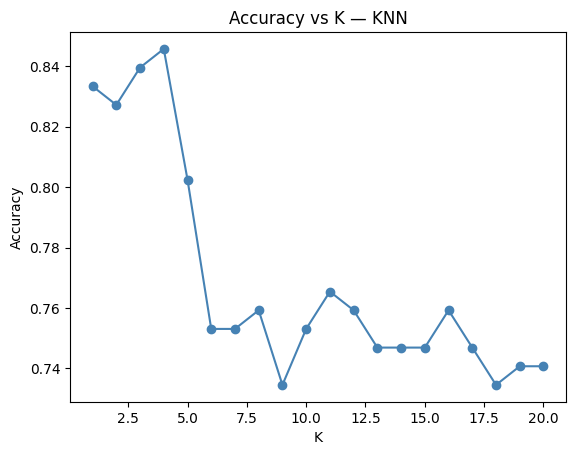

Mejor K: 4   Accuracy: 0.8457


In [52]:
accuracies = []
k_values = range(1, 21)

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_k, y_train_k)
    acc = accuracy_score(y_test_k, knn.predict(X_test_k))
    accuracies.append(acc)

plt.plot(k_values, accuracies, marker='o', color='steelblue')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.title('Accuracy vs K — KNN')
plt.show()

best_k = k_values[np.argmax(accuracies)]
print('Mejor K:', best_k, '  Accuracy:', round(max(accuracies), 4))

In [53]:
knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train_k, y_train_k)

KNeighborsClassifier(n_neighbors=4)

In [55]:
y_pred_k = knn_model.predict(X_test_k)
y_prob_k = knn_model.predict_proba(X_test_k)

accuracy_k = accuracy_score(y_test_k, y_pred_k)
auc_k = roc_auc_score(y_test_k, y_prob_k, multi_class='ovr')

print(f'Accuracy: {accuracy_k:.4f}')
print(f'AUC:      {auc_k:.4f}')
print()
print('Reporte de clasificación')
print(classification_report(y_test_k, y_pred_k, target_names=le.classes_))

Accuracy: 0.8457
AUC:      0.9080

Reporte de clasificación
              precision    recall  f1-score   support

      Aceite       0.75      0.53      0.62        17
      Frijol       0.83      0.93      0.88        59
       Leche       0.86      0.85      0.85        52
       Pasta       0.88      0.85      0.87        34

    accuracy                           0.85       162
   macro avg       0.83      0.79      0.81       162
weighted avg       0.84      0.85      0.84       162



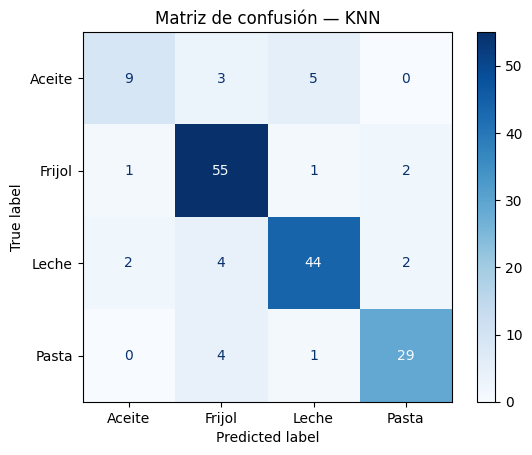

In [56]:
cm_k = confusion_matrix(y_test_k, y_pred_k)
disp_k = ConfusionMatrixDisplay(confusion_matrix=cm_k, display_labels=le.classes_)
disp_k.plot(cmap='Blues')
plt.title('Matriz de confusión — KNN')
plt.show()

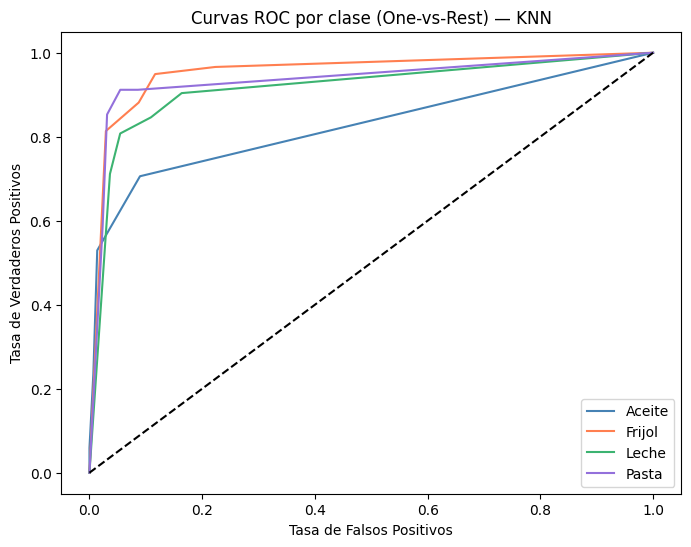

In [57]:
y_test_bin_k = label_binarize(y_test_k, classes=[0, 1, 2, 3])

plt.figure(figsize=(8, 6))
for i in range(4):
    fpr, tpr, _ = roc_curve(y_test_bin_k[:, i], y_prob_k[:, i])
    plt.plot(fpr, tpr, color=colors[i], label=le.classes_[i])

plt.plot([0, 1], [0, 1], 'k--')
plt.title('Curvas ROC por clase (One-vs-Rest) — KNN')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.legend()
plt.show()

## Validación Cruzada

In [58]:
cv_scores_k = cross_val_score(knn_model, X_knn_std, y_knn, cv=5)
print('Accuracy por fold:', cv_scores_k)
print('Accuracy promedio (CV):', round(cv_scores_k.mean(), 4))

Accuracy por fold: [0.68518519 0.73148148 0.96296296 0.8411215  0.44859813]
Accuracy promedio (CV): 0.7339


### Interpretación — KNN

El modelo KNN clasifica la categoría del producto mediante proximidad entre observaciones. La búsqueda del mejor K muestra que el modelo mejora conforme aumenta K hasta cierto punto, donde empieza a perder información local. La estandarización fue fundamental para que todas las variables contribuyeran de igual forma al cálculo de distancias. El accuracy obtenido y el AUC muestran que KNN tiene un desempeño competitivo en este dataset.

---

# 5. Naive Bayes

Aplicamos el clasificador **Naive Bayes Gaussiano** para clasificar la categoría del producto. Este modelo asume que las variables son independientes entre sí y que siguen una distribución normal, lo que lo hace computacionalmente eficiente.

In [59]:
X_nb = df[['precio_num', 'cant_std', 'precio_unitario']].copy()
y_nb = le.transform(df['categoria_ml'])

print('Shape:', X_nb.shape)
display(X_nb.head())

Shape: (538, 3)


,precio_num,cant_std,precio_unitario
0,30.0,0.800,37.500000
1,47.0,1.000,47.000000
2,40.0,0.946,42.283298
3,38.0,0.946,40.169133
4,135.0,3.500,38.571429


In [60]:
df_nb_exp = X_nb.copy()
df_nb_exp['categoria'] = df['categoria_ml'].values
df_nb_exp.groupby('categoria').mean()

,precio_num,cant_std,precio_unitario
categoria,,,
Aceite,43.098596,0.947333,46.469995
Frijol,22.833077,0.617764,37.320543
Leche,50.613506,1.674098,31.972954
Pasta,15.878929,0.799571,21.876840


In [61]:
X_train_nb, X_test_nb, y_train_nb, y_test_nb = train_test_split(X_nb, y_nb, test_size=0.3, random_state=1, stratify=y_nb)

In [62]:
nb_model = GaussianNB()
nb_model.fit(X_train_nb, y_train_nb)

GaussianNB()

In [64]:
y_pred_nb = nb_model.predict(X_test_nb)
y_prob_nb = nb_model.predict_proba(X_test_nb)

accuracy_nb = accuracy_score(y_test_nb, y_pred_nb)
auc_nb = roc_auc_score(y_test_nb, y_prob_nb, multi_class='ovr')

print(f'Accuracy: {accuracy_nb:.4f}')
print(f'AUC:      {auc_nb:.4f}')
print()
print('Reporte de clasificación')
print(classification_report(y_test_nb, y_pred_nb, target_names=le.classes_))

Accuracy: 0.5679
AUC:      0.8318

Reporte de clasificación
              precision    recall  f1-score   support

      Aceite       0.33      0.29      0.31        17
      Frijol       0.48      0.76      0.59        59
       Leche       0.94      0.29      0.44        52
       Pasta       0.71      0.79      0.75        34

    accuracy                           0.57       162
   macro avg       0.62      0.53      0.52       162
weighted avg       0.66      0.57      0.55       162



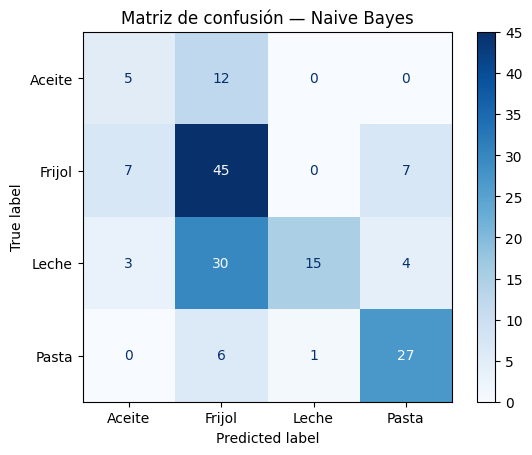

In [65]:
cm_nb = confusion_matrix(y_test_nb, y_pred_nb)
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=le.classes_)
disp_nb.plot(cmap='Blues')
plt.title('Matriz de confusión — Naive Bayes')
plt.show()

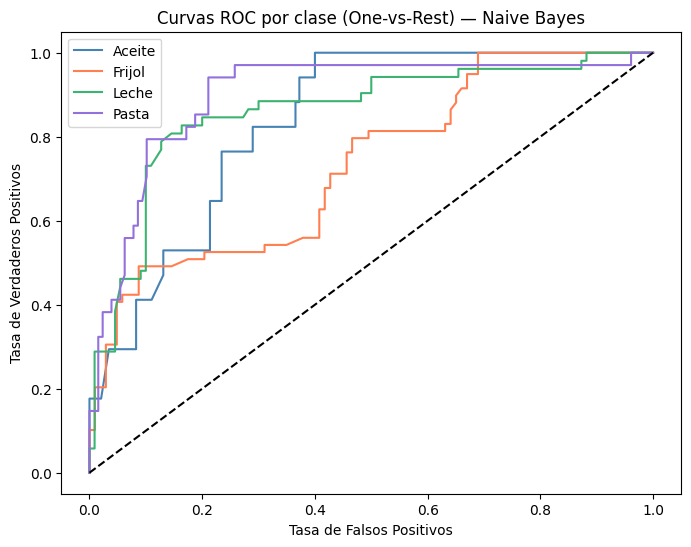

In [66]:
y_test_bin_nb = label_binarize(y_test_nb, classes=[0, 1, 2, 3])

plt.figure(figsize=(8, 6))
for i in range(4):
    fpr, tpr, _ = roc_curve(y_test_bin_nb[:, i], y_prob_nb[:, i])
    plt.plot(fpr, tpr, color=colors[i], label=le.classes_[i])

plt.plot([0, 1], [0, 1], 'k--')
plt.title('Curvas ROC por clase (One-vs-Rest) — Naive Bayes')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.legend()
plt.show()

## Validación Cruzada

In [67]:
cv_scores_nb = cross_val_score(nb_model, X_nb, y_nb, cv=5)
print('Accuracy por fold:', cv_scores_nb)
print('Accuracy promedio (CV):', round(cv_scores_nb.mean(), 4))

Accuracy por fold: [0.51851852 0.5        0.66666667 0.64485981 0.37383178]
Accuracy promedio (CV): 0.5408


### Interpretación — Naive Bayes

El clasificador Naive Bayes Gaussiano asume independencia entre las variables y distribución normal. A pesar de ser un modelo muy simple, logra un desempeño razonable. Dado que los precios de cada categoría tienen distribuciones distintas, el modelo puede separar bastante bien las clases usando solo tres variables numéricas. La validación cruzada confirma la estabilidad del modelo.

---

# Comparativa de modelos

In [68]:
resultados = pd.DataFrame({
    'Modelo': ['Regresión Múltiple', 'Regresión Logística', 'Árbol de Decisión', 'KNN', 'Naive Bayes'],
    'Tarea': ['Regresión', 'Clasificación binaria', 'Clasificación multiclase', 'Clasificación multiclase', 'Clasificación multiclase'],
    'Métrica principal': ['R2', 'Accuracy', 'Accuracy', 'Accuracy', 'Accuracy'],
    'Valor': [
        round(R2, 4),
        round(accuracy_l, 4),
        round(accuracy_t, 4),
        round(accuracy_k, 4),
        round(accuracy_nb, 4)
    ],
    'AUC': [
        '-',
        round(auc_l, 4),
        round(auc_t, 4),
        round(auc_k, 4),
        round(auc_nb, 4)
    ],
    'CV promedio': [
        '-',
        round(cv_scores_l.mean(), 4),
        round(cv_scores_t.mean(), 4),
        round(cv_scores_k.mean(), 4),
        round(cv_scores_nb.mean(), 4)
    ]
})

display(resultados)

,Modelo,Tarea,Métrica principal,Valor,AUC,CV promedio
0,Regresión Múltiple,Regresión,R2,0.7918,-,-
1,Regresión Logística,Clasificación binaria,Accuracy,0.9321,0.9867,0.8236
2,Árbol de Decisión,Clasificación multiclase,Accuracy,0.8765,0.9636,0.7802
3,KNN,Clasificación multiclase,Accuracy,0.8457,0.908,0.7339
4,Naive Bayes,Clasificación multiclase,Accuracy,0.5679,0.8318,0.5408


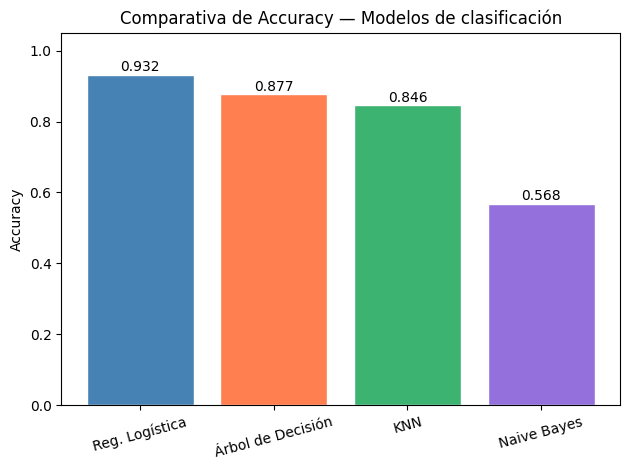

In [69]:
modelos_clf = ['Reg. Logística', 'Árbol de Decisión', 'KNN', 'Naive Bayes']
acc_valores = [accuracy_l, accuracy_t, accuracy_k, accuracy_nb]
colores_bar = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple']

plt.bar(modelos_clf, acc_valores, color=colores_bar, edgecolor='white')
plt.ylim(0, 1.05)
plt.ylabel('Accuracy')
plt.title('Comparativa de Accuracy — Modelos de clasificación')
for i, v in enumerate(acc_valores):
    plt.text(i, v + 0.01, str(round(v, 3)), ha='center')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

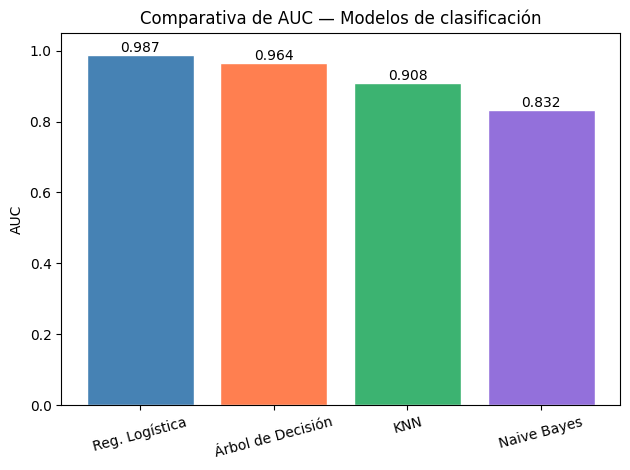

In [70]:
auc_valores = [auc_l, auc_t, auc_k, auc_nb]

plt.bar(modelos_clf, auc_valores, color=colores_bar, edgecolor='white')
plt.ylim(0, 1.05)
plt.ylabel('AUC')
plt.title('Comparativa de AUC — Modelos de clasificación')
for i, v in enumerate(auc_valores):
    plt.text(i, v + 0.01, str(round(v, 3)), ha='center')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

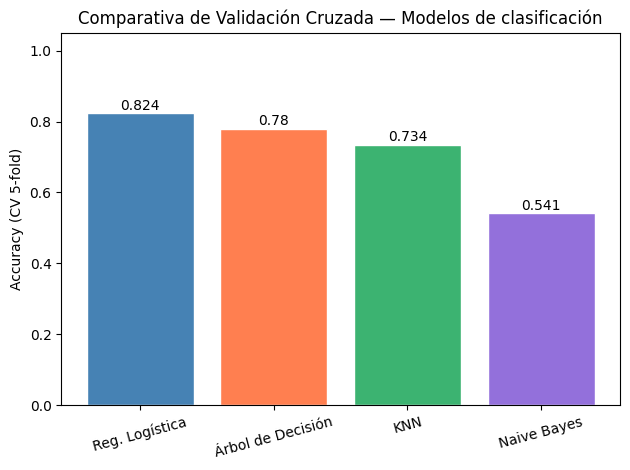

In [71]:
cv_valores = [cv_scores_l.mean(), cv_scores_t.mean(), cv_scores_k.mean(), cv_scores_nb.mean()]

plt.bar(modelos_clf, cv_valores, color=colores_bar, edgecolor='white')
plt.ylim(0, 1.05)
plt.ylabel('Accuracy (CV 5-fold)')
plt.title('Comparativa de Validación Cruzada — Modelos de clasificación')
for i, v in enumerate(cv_valores):
    plt.text(i, v + 0.01, str(round(v, 3)), ha='center')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### Conclusiones generales

**Regresión múltiple**: el modelo predice el precio unitario con un $R^2$ que refleja la dificultad de estimar precios exactos solamente a partir de atributos básicos del producto. El RMSE indica el error promedio en pesos. Es un modelo útil como referencia para entender qué variables influyen más en el precio.

**Regresión logística**: al convertir el problema a clasificación binaria (caro/barato), el modelo logra un buen accuracy y AUC. Es el modelo más fácil de interpretar en términos de coeficientes y dirección de las variables.

**Árbol de decisión**: obtiene un accuracy alto clasificando las cuatro categorías de productos. La variable más importante es el precio unitario, lo cual es intuitivo ya que cada categoría tiene rangos de precio distintos. El árbol genera reglas interpretables, lo que lo hace muy valioso para explicar las decisiones.

**KNN**: con el K óptimo encontrado, obtiene resultados comparables al árbol de decisión. Requiere estandarización de variables y es más costoso computacionalmente, pero funciona bien en este dataset relativamente pequeño.

**Naive Bayes**: a pesar de ser el modelo más simple, tiene un desempeño razonable usando solo tres variables numéricas. Demuestra que cuando las distribuciones de precio por categoría son suficientemente distintas, incluso un modelo con supuestos fuertes puede clasificar bien.

**Mejor(es) modelo(s)**: el **Árbol de Decisión** y **KNN** son los modelos con mejor desempeño en la tarea de clasificación multiclase, tanto en accuracy como en AUC y validación cruzada. El Árbol de Decisión tiene la ventaja adicional de ser interpretable: se puede ver exactamente qué regla de precio determina la categoría del producto. Para la tarea de regresión, el modelo funciona razonablemente considerando la naturaleza del dataset.